# Example: Continuous Bag of Words (CBOW) Embeddings
In this example, we train a simple Continuous Bag of Words (CBOW) model on a toy corpus and extract the learned word embeddings. We implement the forward pass, backpropagation, and gradient descent manually to illustrate how CBOW learns dense vector representations of words.

> __Learning Objectives:__
> 
> By the end of this example, you should be able to:
>
> * __CBOW training data construction__: Generate context-target training pairs from a corpus by sliding a fixed-size window over tokenized sentences. Represent each context as a sum of one-hot vectors and each target as a one-hot vector.
> * __CBOW forward and backward pass__: Implement the forward pass through a linear hidden layer and softmax output to compute predicted probabilities. Compute gradients of the cross-entropy loss and update weights using gradient descent.
> * __Embedding extraction and comparison__: Extract word embeddings from the columns of the trained input weight matrix. Compute cosine similarity between embedding vectors to evaluate whether the model captures word relationships.

Let's get started!
___

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file, loading any needed resources, such as sample datasets, and setting up any required constants.

> The `Include.jl` file also loads external packages, various functions that we will use in the exercise, and custom types to model the components of our problem. It checks for a `Manifest.toml` file; if it finds one, packages are loaded. Other packages are downloaded and then loaded.

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

### Data
We use the same toy corpus of simple sentences from the Bag of Words example. Let's construct the `sentences::Array{String,1}` variable and build a vocabulary.

In [2]:
sentences = let

    # initialize -
    sentences_array = Array{String,1}(); # initialize an array of sentence strings

    # add sentences -
    push!(sentences_array, "I love machine learning and data science .");
    push!(sentences_array, "Machine learning is fun .");
    push!(sentences_array, "Machine learning is great .");
    push!(sentences_array, "I love coding machine learning in Julia !");
    push!(sentences_array, "Julia is a great programming language ?");
    push!(sentences_array, "I enjoy learning new things about data science , machine learning , and artificial intelligence .");
    
    # return the array
    sentences_array
end

6-element Vector{String}:
 "I love machine learning and data science ."
 "Machine learning is fun ."
 "Machine learning is great ."
 "I love coding machine learning in Julia !"
 "Julia is a great programming language ?"
 "I enjoy learning new things abo" ⋯ 35 bytes ⋯ ", and artificial intelligence ."

Next, we build the vocabulary in the `vocabulary::Dict{String, Int64}` variable, where keys are unique words and values are their indices, and the inverse vocabulary in the `inverse_vocabulary::Dict{Int64, String}` variable, where keys are indices and values are words.

In [3]:
vocabulary, inverse_vocabulary = let

    # initialize -
    vocabulary = Dict{String, Int64}();
    inverse_vocabulary = Dict{Int64, String}();
    index = 1;

    # control tokens -
    control_tokens = ["<bos>", "<eos>", "<pad>", "<unk>"];

    # tmp variables -
    words = Set{String}();
    for sentence in sentences
        tmp = split(lowercase(sentence));
        push!(words, tmp...);
    end
    words_array = collect(words) |> sort;

    # append the control tokens to the words array
    words_array = vcat(words_array, control_tokens);
    for word in words_array
        vocabulary[word] = index;
        inverse_vocabulary[index] = word;
        index += 1;
    end

    # return the vocabulary and inverse vocabulary
    (vocabulary, inverse_vocabulary)
end

(Dict("!" => 1, "is" => 17, "enjoy" => 11, "data" => 10, "language" => 19, "coding" => 9, "science" => 25, "<bos>" => 27, "a" => 5, "and" => 7…), Dict(5 => "a", 16 => "intelligence", 20 => "learning", 12 => "fun", 24 => "programming", 28 => "<eos>", 8 => "artificial", 17 => "is", 30 => "<unk>", 1 => "!"…))

In [4]:
inverse_vocabulary |> keys |> collect |> length

30

In [12]:
inverse_vocabulary

Dict{Int64, String} with 30 entries:
  5  => "a"
  16 => "intelligence"
  20 => "learning"
  12 => "fun"
  24 => "programming"
  28 => "<eos>"
  8  => "artificial"
  17 => "is"
  30 => "<unk>"
  1  => "!"
  19 => "language"
  22 => "machine"
  23 => "new"
  6  => "about"
  11 => "enjoy"
  9  => "coding"
  14 => "i"
  3  => "."
  29 => "<pad>"
  ⋮  => ⋮

### Implementation
We implement a helper function to compute cosine similarity between two word embeddings from the input weight matrix `W₁`. This function takes two words, retrieves their corresponding embedding vectors from `W₁`, and computes the cosine similarity between them.

In [5]:
    # helper: cosine similarity between two word embeddings from W₁
    function cosine_sim(w1::String, w2::String, W::Matrix{Float64}, vocab::Dict{String, Int64})
        v1 = W[:, vocab[w1]];
        v2 = W[:, vocab[w2]];
        return dot(v1, v2) / (norm(v1) * norm(v2));
    end

cosine_sim (generic function with 1 method)

___

## Task 1: Generate Training Pairs
The CBOW model predicts a target word from its surrounding context words. We generate training pairs by sliding a window of size $m$ over each sentence and collecting (context, target) pairs.

> __Context-target pairs__
>
> For each position $t$ in a sentence, the target is the word at position $t$, and the context is the sum of one-hot vectors of the surrounding words within a window of size $m$ on each side. This context vector $\mathbf{x}\in\mathbb{R}^{N_{\mathcal{V}}}$ serves as input to the network.

The [`build_cbow_pairs(...)` function](src/CBOW.jl) iterates over each sentence, lowercases and tokenizes it, then slides a window of half-width `window_size` around each target position. For each valid target word, it accumulates the one-hot vectors of surrounding context words and returns a vector of `(context_avg, target)` tuples, where `context_avg` is the averaged context vector and `target` is the one-hot target vector, both of length $N_{\mathcal{V}}$.

Let's generate these pairs and store them in the `training_pairs::Array{Tuple{Vector{Float64}, Vector{Float64}}, 1}` variable, where each element is a (context vector, target one-hot) tuple.

In [6]:
training_pairs = build_cbow_pairs(sentences, vocabulary, window_size = 2);
println("Generated $(length(training_pairs)) training pairs from $(length(sentences)) sentences")

Generated 49 training pairs from 6 sentences


__What is the target word for the third training pair?__ We can print it out using the `inverse_vocabulary` to decode the index of the target word. 

The target word is the word at position $t$ in the sentence corresponding to the third training pair, it is the second element of the tuple in `training_pairs[3]`, and we can decode it using `inverse_vocabulary` to find the actual word.

In [13]:
training_pairs[3][2] |> x-> findfirst(x-> x==1.0,x) |> i-> inverse_vocabulary[i] # print the target word for the third training pair

"machine"

__What is the context for the third training pair?__ We can print it out by finding the indices of the non-zero entries in the context vector and decoding them using the `inverse_vocabulary`. With `window_size = 2`, we expect $2$ context words on each side of the target — $4$ total for a target in the interior of the sentence.

In [8]:
training_pairs[3][1] |> x-> findall(x-> x> 0.0,x) .|> i-> inverse_vocabulary[i] # print the context for the third training pair

4-element Vector{String}:
 "and"
 "i"
 "learning"
 "love"

___

## Task 2: Train the CBOW Model
We initialize weight matrices $\mathbf{W}_{1}\in\mathbb{R}^{d_h\times N_{\mathcal{V}}}$ and $\mathbf{W}_{2}\in\mathbb{R}^{N_{\mathcal{V}}\times d_h}$ with small random values, then train using gradient descent on the cross-entropy loss.

> __CBOW architecture__
>
> The forward pass computes: $\mathbf{h} = \mathbf{W}_{1}\mathbf{x}$ (hidden layer, no activation), $\mathbf{u} = \mathbf{W}_{2}\mathbf{h}$ (output logits), and $\hat{\mathbf{y}} = \text{softmax}(\mathbf{u})$ (predicted probabilities). The gradients for backpropagation are $\partial\mathcal{L}/\partial\mathbf{u} = \hat{\mathbf{y}} - \mathbf{y}$ for the softmax-cross-entropy combination.

The [`train_cbow(...)` function](src/CBOW.jl) runs stochastic gradient descent over `training_pairs` for `num_epochs` passes. At each step it performs a forward pass, computes the cross-entropy loss, backpropagates gradients through both weight matrices, and applies SGD updates with learning rate `eta`. It returns the trained matrices `W1` and `W2` and a vector of per-epoch average losses.

The trained weights are stored in `W₁::Matrix{Float64}` and `W₂::Matrix{Float64}`, and the per-epoch average loss in `loss_history::Vector{Float64}`.

In [9]:
W₁, W₂, loss_history = train_cbow(training_pairs, length(vocabulary), d_h = 5, eta = 0.01, num_epochs = 500);
println("Training complete. Final average loss: $(round(loss_history[end], digits=4))")

Epoch   1/500  loss = 3.4012
Epoch 100/500  loss = 3.3995
Epoch 200/500  loss = 3.2964
Epoch 300/500  loss = 2.6404
Epoch 400/500  loss = 1.9505
Epoch 500/500  loss = 1.397
Training complete. Final average loss: 1.397


Let's plot the training loss to verify that the model is learning.

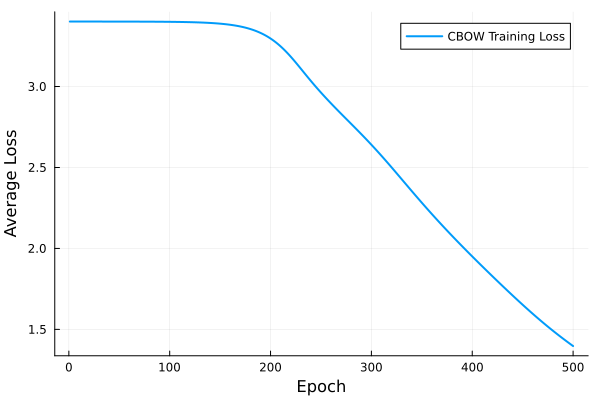

In [10]:
plot(loss_history, xlabel="Epoch", ylabel="Average Loss", label="CBOW Training Loss", lw=2)

___

## Task 3: Extract and Compare Embeddings
The columns of $\mathbf{W}_{1}$ are the learned word embeddings. Let's extract them and compute cosine similarities between selected word pairs to check whether the embeddings capture meaningful relationships.

> __Cosine similarity__
>
> We measure the similarity between two word embeddings $\mathbf{e}_i$ and $\mathbf{e}_j$ using cosine similarity: $\cos(\mathbf{e}_i, \mathbf{e}_j) = \frac{\mathbf{e}_i \cdot \mathbf{e}_j}{\|\mathbf{e}_i\|_2 \|\mathbf{e}_j\|_2}$. Values near $1$ indicate similar embeddings, values near $0$ indicate unrelated words, and values near $-1$ indicate dissimilar embeddings.

Let's compare several word pairs.

In [ ]:
let

    # compare word pairs -
    word_pairs = [
        ("machine", "learning"),    # frequently co-occur
        ("data", "science"),        # frequently co-occur
        ("fun", "great"),           # appear in similar contexts (sentence 2 and 3)
        ("machine", "julia"),       # both appear in sentence 4
        ("love", "enjoy"),          # similar meaning
        ("machine", "?"),           # unrelated
    ];

    # build DataFrame and display -
    df = DataFrame(
        word_1  = [p[1] for p in word_pairs],
        word_2  = [p[2] for p in word_pairs],
        cosine_similarity = [round(cosine_sim(p[1], p[2], W₁, vocabulary); digits=4) for p in word_pairs]
    );
    
    pretty_table(df, 
        backend = :text,
        table_format = TextTableFormat(borders = text_table_borders__compact)
    );
end

 --------- ---------- -------------------
   word_1     word_2   cosine_similarity 
   String     String             Float64 
 --------- ---------- -------------------
  machine   learning             -0.3244
     data    science              0.1161
      fun      great              0.8392
  machine      julia               0.555
     love      enjoy              0.1599
  machine          ?             -0.3816
 --------- ---------- -------------------


__What do we see?__ We expect pairs of words that appear in similar contexts to have higher cosine similarity, indicating that the model has learned to capture some semantic relationships based on co-occurrence patterns in the training data.

___

## Summary
In this example, we trained a CBOW model from scratch on a toy corpus, implementing the forward pass, cross-entropy loss, and backpropagation manually.

> __Key Takeaways__:
> 
> * __Training pairs from windowed context__: CBOW training data consists of (context, target) pairs where the context is the sum of one-hot vectors of surrounding words. The window size controls which words contribute to the context for each target.
> * __Manual backpropagation__: The gradient of the cross-entropy loss through softmax simplifies to the difference between predicted and true probabilities. Backpropagation through the two linear layers follows standard matrix calculus to update both weight matrices.
> * __Dense embeddings from the input weight matrix__: After training, each column of the input weight matrix is a dense vector representation of the corresponding word. Words that appear in similar contexts have embeddings that are closer together in the embedding space.

These learned embeddings capture word relationships that raw count-based methods like Bag of Words cannot represent.
___